# PhysiCell Diffusion Uptake Sweep with a Single Central Sink

This notebook runs the diffusion uptake sweep with one sink cell placed at the origin, corresponding to the central voxel. It keeps the original parameter sweep while excluding the 2 and 3 um voxel sizes.

In [16]:
from pathlib import Path
import os
import shutil
import subprocess
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pctk import multicellds

ROOT = Path('/home/tntiniak/Work/observatory_benchmark')
CODE_DIR = ROOT / 'PhysiCell' / 'code'
CONFIG_DIR = CODE_DIR / 'config'
TEMPLATE_XML = CODE_DIR / 'config' / '__tmp_uptake_tune.xml'
WORKING_XML = CODE_DIR / 'config' / '__generated_uptake_single_central_sink_case.xml'
FIXED_CELL_POSITIONS_CSV = CONFIG_DIR / 'single_central_sink_sweep.csv'
FIXED_RESULTS_ROOT = ROOT / 'PhysiCell' / 'results' / 'diffusion_uptake_single_central_sink'
ORIGIN_RESULTS_ROOT = ROOT / 'PhysiCell' / 'results' / 'diffusion_uptake_sweep'
ANALYTICAL_CSV = ROOT / 'analytical_solutions' / 'diffusion' / 'SingleCellSink' / 'analytical_values.csv'
OUTPUT_FILENAME = 'physicell_uptake_plot_data.csv'

VOXEL_SIZES_UM = [5.0, 10.0, 20.0, 40.0]
UPTAKE_RATES_PER_MIN = [12044]
DT_DIFFUSION_MIN = [0.005, 0.01, 0.1]
TOTAL_VOLUMES_UM3 = [1.0, 523.0, 1000.0]
PARAM_COLUMNS = ['dx_um', 'dt_diffusion_min', 'uptake_rate_per_min', 'total_volume_um3']

plt.rcParams.update({
    'figure.dpi': 160,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 8,
})

FIXED_RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

In [17]:
def format_token(value: float) -> str:
    formatted = f'{value:g}'
    return formatted.replace('-', 'm').replace('.', 'p').replace('+', '')


def build_run_id(dx_um: float, uptake_rate: float, dt_diffusion: float, total_volume_um3: float) -> str:
    return (
        f'dx_{format_token(dx_um)}um__'
        f'uptake_{format_token(uptake_rate)}__'
        f'dtdiff_{format_token(dt_diffusion)}min__'
        f'volume_{format_token(total_volume_um3)}um3'
    )


FIXED_CELL_POSITIONS_UM = np.array([
    [0.0, 0.0, 0.0, 0.0],
], dtype=float)


def write_fixed_cell_position_csvs() -> None:
    np.savetxt(FIXED_CELL_POSITIONS_CSV, FIXED_CELL_POSITIONS_UM, delimiter=',', fmt='%.10g')


def nearest_axis_index(axis_values: np.ndarray, coordinate: float) -> int:
    return int(np.abs(axis_values - coordinate).argmin())


def trilinear_interpolate_origin(microenvironment: np.ndarray) -> float:
    x_axis = np.unique(microenvironment[0])
    y_axis = np.unique(microenvironment[1])
    z_axis = np.unique(microenvironment[2])
    concentration_field = microenvironment[4]

    def bracketing_indices(axis_values: np.ndarray) -> tuple[int, int]:
        right = int(np.searchsorted(axis_values, 0.0, side='left'))
        if right <= 0:
            right = 1
        if right >= len(axis_values):
            right = len(axis_values) - 1
        left = right - 1
        return left, right

    x0, x1 = bracketing_indices(x_axis)
    y0, y1 = bracketing_indices(y_axis)
    z0, z1 = bracketing_indices(z_axis)
    x_lo, x_hi = float(x_axis[x0]), float(x_axis[x1])
    y_lo, y_hi = float(y_axis[y0]), float(y_axis[y1])
    z_lo, z_hi = float(z_axis[z0]), float(z_axis[z1])

    def weight(value: float, low: float, high: float) -> float:
        if high == low:
            return 0.0
        return (value - low) / (high - low)

    wx = weight(0.0, x_lo, x_hi)
    wy = weight(0.0, y_lo, y_hi)
    wz = weight(0.0, z_lo, z_hi)
    dims = (len(x_axis), len(y_axis), len(z_axis))
    values = {}
    for ix in [x0, x1]:
        for iy in [y0, y1]:
            for iz in [z0, z1]:
                flat_index = np.ravel_multi_index((ix, iy, iz), dims)
                values[(ix, iy, iz)] = concentration_field[flat_index] / 602.2

    interpolated = 0.0
    for ix, x_weight in [(x0, 1.0 - wx), (x1, wx)]:
        for iy, y_weight in [(y0, 1.0 - wy), (y1, wy)]:
            for iz, z_weight in [(z0, 1.0 - wz), (z1, wz)]:
                interpolated += x_weight * y_weight * z_weight * values[(ix, iy, iz)]
    return interpolated


def configure_case_xml(template_xml: Path, output_xml: Path, output_dir: Path, dx_um: float, uptake_rate: float, dt_diffusion: float, total_volume_um3: float) -> None:
    tree = ET.parse(template_xml)
    root = tree.getroot()

    for axis in ['dx', 'dy', 'dz']:
        node = root.find(f'.//domain/{axis}')
        if node is None:
            raise KeyError(f'Missing domain/{axis} in {template_xml}')
        node.text = str(dx_um)

    dt_node = root.find('.//overall/dt_diffusion')
    if dt_node is None:
        raise KeyError(f'Missing overall/dt_diffusion in {template_xml}')
    dt_node.text = str(dt_diffusion)

    uptake_node = root.find('.//cell_definitions//secretion//substrate/uptake_rate')
    if uptake_node is None:
        raise KeyError(f'Missing uptake_rate in {template_xml}')
    uptake_node.text = str(uptake_rate)

    total_volume_node = root.find('.//cell_definitions//volume/total')
    if total_volume_node is None:
        raise KeyError(f'Missing volume/total in {template_xml}')
    total_volume_node.text = str(total_volume_um3)

    nuclear_volume_node = root.find('.//cell_definitions//volume/nuclear')
    if nuclear_volume_node is None:
        raise KeyError(f'Missing volume/nuclear in {template_xml}')
    nuclear_volume_node.text = str(0.1 * total_volume_um3)

    save_folder_node = root.find('.//save/folder')
    if save_folder_node is None:
        raise KeyError(f'Missing save/folder in {template_xml}')
    save_folder_node.text = os.path.relpath(output_dir, CODE_DIR)

    tree.write(output_xml, encoding='utf-8', xml_declaration=False)


def run_physicell_case(case_xml: Path) -> None:
    try:
        subprocess.run(['./project', str(case_xml)], cwd=CODE_DIR, check=True, capture_output=True, text=True)
    except subprocess.CalledProcessError as exc:
        raise RuntimeError(f'PhysiCell run failed for {case_xml}\nExit code: {exc.returncode}\nSTDOUT tail:\n{exc.stdout[-4000:]}\nSTDERR tail:\n{exc.stderr[-4000:]}') from exc


def load_run(folder: Path, settings_xml: Path, run_id: str, dx_um: float, uptake_rate: float, dt_diffusion: float, total_volume_um3: float) -> pd.DataFrame:
    settings_root = ET.parse(settings_xml).getroot()
    cell_positions_filename = settings_root.findtext('.//initial_conditions/cell_positions/filename')
    if cell_positions_filename is None:
        raise ValueError(f'No cell positions filename found in {settings_xml}')

    cell_positions_path = settings_xml.parent / cell_positions_filename
    cell_positions = np.loadtxt(cell_positions_path, delimiter=',', usecols=(0, 1, 2), ndmin=2)
    output_xml_paths = sorted(folder.glob('output*.xml'))
    if not output_xml_paths:
        raise FileNotFoundError(f'No output XML files found in {folder}')

    output_times = []
    valid_xml_count = 0
    for xml_path in output_xml_paths:
        if xml_path.stat().st_size == 0:
            continue
        try:
            root = ET.parse(xml_path).getroot()
        except ET.ParseError:
            continue
        current_time_text = root.findtext('.//current_time')
        if current_time_text is None:
            continue
        output_times.append(float(current_time_text))
        valid_xml_count += 1

    if valid_xml_count == 0:
        raise ValueError(f'No parseable output XML snapshots found in {folder}')

    reader = multicellds.MultiCellDS(output_folder=str(folder))
    average_uM = []
    origin_center_uM = []
    center_uM = []
    cell_voxel_average_uM = []
    center_index = None
    cell_voxel_indices = None

    for _, microenvironment in reader.microenvironment_as_matrix_iterator():
        concentration_field = microenvironment[4]
        if center_index is None:
            x_axis = np.unique(microenvironment[0])
            y_axis = np.unique(microenvironment[1])
            z_axis = np.unique(microenvironment[2])
            dims = (len(x_axis), len(y_axis), len(z_axis))
            center_index = np.ravel_multi_index((nearest_axis_index(x_axis, 0.0), nearest_axis_index(y_axis, 0.0), nearest_axis_index(z_axis, 0.0)), dims)
            cell_voxel_indices = []
            for x_cell, y_cell, z_cell in cell_positions:
                voxel_index = np.ravel_multi_index((nearest_axis_index(x_axis, x_cell), nearest_axis_index(y_axis, y_cell), nearest_axis_index(z_axis, z_cell)), dims)
                cell_voxel_indices.append(voxel_index)
            cell_voxel_indices = np.unique(cell_voxel_indices)

        average_uM.append(concentration_field.mean() / 602.2)
        origin_center_uM.append(trilinear_interpolate_origin(microenvironment))
        center_uM.append(concentration_field[center_index] / 602.2)
        cell_voxel_average_uM.append(concentration_field[cell_voxel_indices].mean() / 602.2)

    return pd.DataFrame({
        'tool': 'PhysiCell',
        'run_id': run_id,
        'dx_um': dx_um,
        'uptake_rate_per_min': uptake_rate,
        'dt_diffusion_min': dt_diffusion,
        'total_volume_um3': total_volume_um3,
        'nuclear_volume_um3': 0.1 * total_volume_um3,
        'time_min': np.round(np.array(output_times, dtype=float), 4),
        'average_uM': np.array(average_uM, dtype=float),
        'origin_center_uM': np.array(origin_center_uM, dtype=float),
        'center_uM': np.array(center_uM, dtype=float),
        'cell_voxel_average_uM': np.array(cell_voxel_average_uM, dtype=float),
    })


def style_axis(axis) -> None:
    axis.grid(True, alpha=0.3)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)

In [18]:
_configure_case_xml_without_cell_filename = configure_case_xml


def configure_case_xml(template_xml: Path, output_xml: Path, output_dir: Path, dx_um: float, uptake_rate: float, dt_diffusion: float, total_volume_um3: float) -> None:
    _configure_case_xml_without_cell_filename(template_xml, output_xml, output_dir, dx_um, uptake_rate, dt_diffusion, total_volume_um3)
    tree = ET.parse(output_xml)
    root = tree.getroot()

    cell_positions_node = root.find('.//initial_conditions/cell_positions')
    if cell_positions_node is None:
        raise KeyError(f'Missing initial_conditions/cell_positions in {template_xml}')

    folder_node = cell_positions_node.find('folder')
    if folder_node is None:
        raise KeyError(f'Missing initial_conditions/cell_positions/folder in {template_xml}')
    folder_node.text = './' + os.path.relpath(FIXED_CELL_POSITIONS_CSV.parent, CODE_DIR)

    filename_node = cell_positions_node.find('filename')
    if filename_node is None:
        raise KeyError(f'Missing initial_conditions/cell_positions/filename in {template_xml}')
    filename_node.text = FIXED_CELL_POSITIONS_CSV.name

    tree.write(output_xml, encoding='utf-8', xml_declaration=False)

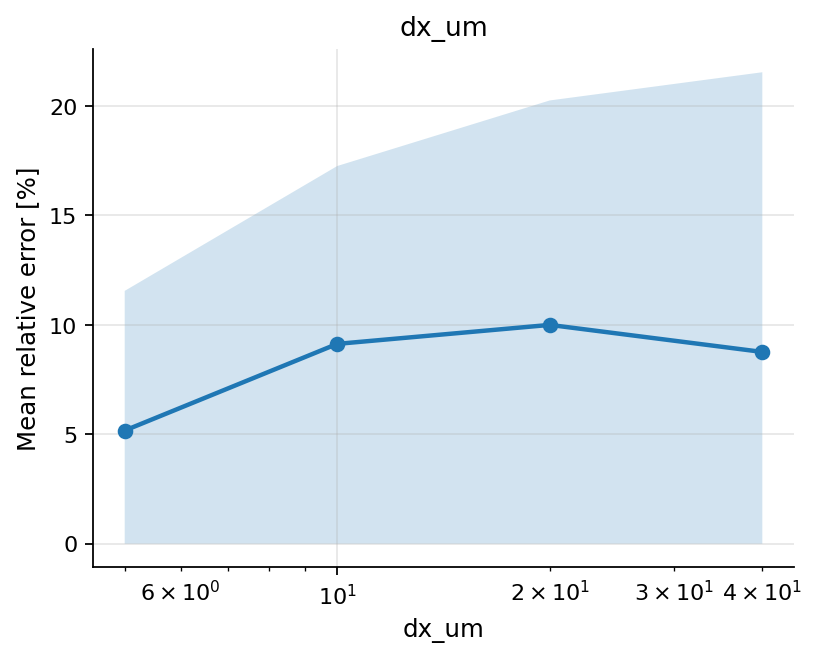

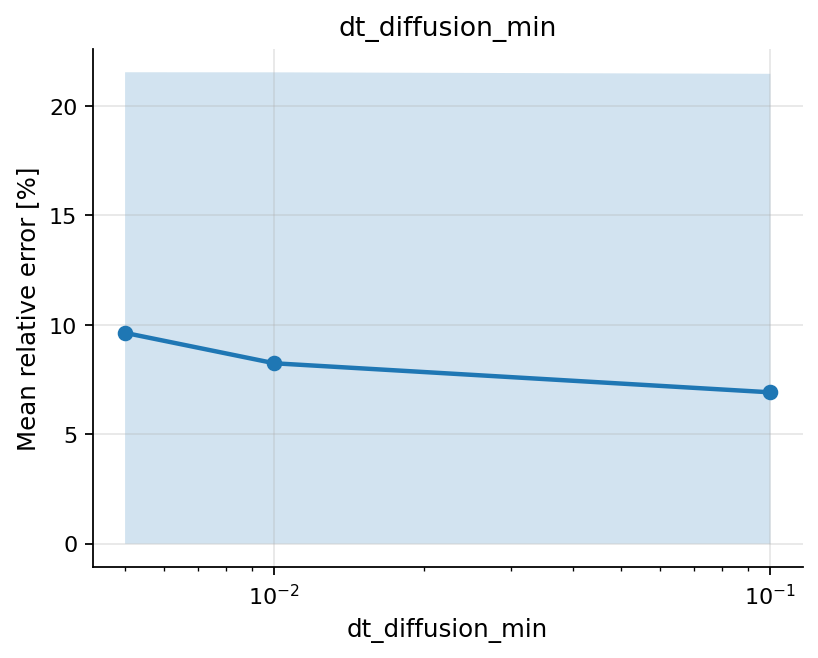

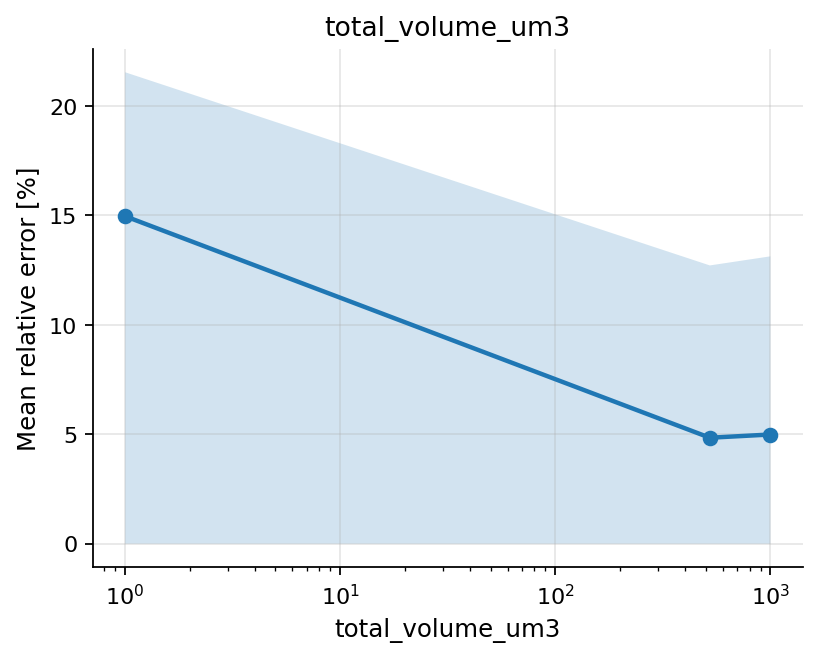

,run_id,output_dir,dx_um,uptake_rate_per_min,dt_diffusion_min,total_volume_um3,mean_origin_relative_error_percent,final_origin_center_uM
0,dx_40um__uptake_12044__dtdiff_0p005min__volume...,/home/tntiniak/Work/observatory_benchmark/Phys...,40.0,12044,0.005,1.0,0.077583,9.909630
1,dx_40um__uptake_12044__dtdiff_0p01min__volume_...,/home/tntiniak/Work/observatory_benchmark/Phys...,40.0,12044,0.010,1.0,0.078381,9.908727
2,dx_40um__uptake_12044__dtdiff_0p1min__volume_1um3,/home/tntiniak/Work/observatory_benchmark/Phys...,40.0,12044,0.100,1.0,0.092812,9.892378
3,dx_20um__uptake_12044__dtdiff_0p005min__volume...,/home/tntiniak/Work/observatory_benchmark/Phys...,20.0,12044,0.005,1.0,0.204695,9.777154
4,dx_20um__uptake_12044__dtdiff_0p01min__volume_...,/home/tntiniak/Work/observatory_benchmark/Phys...,20.0,12044,0.010,1.0,0.210322,9.771360
5,dx_20um__uptake_12044__dtdiff_0p1min__volume_1um3,/home/tntiniak/Work/observatory_benchmark/Phys...,20.0,12044,0.100,1.0,0.305417,9.673468
6,dx_10um__uptake_12044__dtdiff_0p005min__volume...,/home/tntiniak/Work/observatory_benchmark/Phys...,10.0,12044,0.005,1.0,0.452427,9.526891
7,dx_10um__uptake_12044__dtdiff_0p01min__volume_...,/home/tntiniak/Work/observatory_benchmark/Phys...,10.0,12044,0.010,1.0,0.483140,9.496235
8,dx_10um__uptake_12044__dtdiff_0p1min__volume_1um3,/home/tntiniak/Work/observatory_benchmark/Phys...,10.0,12044,0.100,1.0,0.799165,9.180988
9,dx_5um__uptake_12044__dtdiff_0p005min__volume_...,/home/tntiniak/Work/observatory_benchmark/Phys...,5.0,12044,0.005,1.0,0.886048,9.093315


,run_id,dx_um,uptake_rate_per_min,dt_diffusion_min,total_volume_um3,nuclear_volume_um3,point_count,mean_absolute_error_uM,max_absolute_error_uM,rmse_uM,mean_relative_error_percent,max_relative_error_percent,rmse_percent
0,dx_5um__uptake_12044__dtdiff_0p01min__volume_1...,5.0,12044,0.010,1000.0,100.0,11,0.036990,0.082195,0.043238,0.450975,0.998887,0.526881
1,dx_5um__uptake_12044__dtdiff_0p01min__volume_5...,5.0,12044,0.010,523.0,52.3,11,0.038270,0.083558,0.044438,0.466580,1.015455,0.541523
2,dx_20um__uptake_12044__dtdiff_0p1min__volume_1...,20.0,12044,0.100,1000.0,100.0,11,0.122783,0.529632,0.199509,1.495723,6.436460,2.427895
3,dx_20um__uptake_12044__dtdiff_0p1min__volume_5...,20.0,12044,0.100,523.0,52.3,11,0.126117,0.537060,0.203848,1.536370,6.526734,2.480794
4,dx_40um__uptake_12044__dtdiff_0p1min__volume_5...,40.0,12044,0.100,523.0,52.3,11,0.196133,0.636674,0.264201,2.390389,7.737311,3.216758
5,dx_40um__uptake_12044__dtdiff_0p1min__volume_1...,40.0,12044,0.100,1000.0,100.0,11,0.196757,0.584455,0.254853,2.398306,7.102714,3.103679
6,dx_5um__uptake_12044__dtdiff_0p005min__volume_...,5.0,12044,0.005,523.0,52.3,11,0.290046,0.354091,0.305899,3.538647,4.321892,3.732456
7,dx_5um__uptake_12044__dtdiff_0p005min__volume_...,5.0,12044,0.005,1000.0,100.0,11,0.292565,0.356898,0.308531,3.569379,4.356153,3.764557
8,dx_40um__uptake_12044__dtdiff_0p01min__volume_...,40.0,12044,0.010,523.0,52.3,11,0.305463,0.568683,0.357672,3.726642,6.941119,4.364160
9,dx_40um__uptake_12044__dtdiff_0p005min__volume...,40.0,12044,0.005,523.0,52.3,11,0.318896,0.593274,0.373640,3.890712,7.241267,4.559293


,parameter,spread
2,total_volume_um3,10.118882
0,dx_um,4.826706
1,dt_diffusion_min,2.716489


In [19]:
write_fixed_cell_position_csvs()

summary_rows = []
run_frames = []

for dx_um in VOXEL_SIZES_UM:
    for uptake_rate in UPTAKE_RATES_PER_MIN:
        for dt_diffusion in DT_DIFFUSION_MIN:
            for total_volume_um3 in TOTAL_VOLUMES_UM3:
                run_id = build_run_id(dx_um, uptake_rate, dt_diffusion, total_volume_um3)
                output_dir = FIXED_RESULTS_ROOT / run_id
                if output_dir.exists():
                    shutil.rmtree(output_dir)
                output_dir.mkdir(parents=True, exist_ok=True)

                configure_case_xml(TEMPLATE_XML, WORKING_XML, output_dir, dx_um, uptake_rate, dt_diffusion, total_volume_um3)
                run_physicell_case(WORKING_XML)

                run_frame = load_run(output_dir, WORKING_XML, run_id, dx_um, uptake_rate, dt_diffusion, total_volume_um3)
                run_frame.to_csv(output_dir / OUTPUT_FILENAME, index=False)
                run_frames.append(run_frame)
                summary_rows.append({
                    'run_id': run_id,
                    'output_dir': str(output_dir),
                    'dx_um': dx_um,
                    'uptake_rate_per_min': uptake_rate,
                    'dt_diffusion_min': dt_diffusion,
                    'total_volume_um3': total_volume_um3,
                    'mean_origin_relative_error_percent': float((run_frame['origin_center_uM'] - run_frame['average_uM']).abs().mean()),
                    'final_origin_center_uM': float(run_frame['origin_center_uM'].iloc[-1]),
                })

all_runs = pd.concat(run_frames, ignore_index=True)
run_summary = pd.DataFrame(summary_rows).sort_values(['mean_origin_relative_error_percent', 'dx_um', 'dt_diffusion_min', 'total_volume_um3']).reset_index(drop=True)
run_summary.to_csv(FIXED_RESULTS_ROOT / 'run_summary.csv', index=False)
run_summary

analytical_df = pd.read_csv(ANALYTICAL_CSV, usecols=['time_min', 'center_concentration_uM', 'average_concentration_uM']).copy()
analytical_df['time_min'] = analytical_df['time_min'].round(2)

comparison = all_runs.copy()
comparison['time_min'] = comparison['time_min'].round(2)
comparison = comparison.merge(analytical_df, on='time_min', how='inner', validate='many_to_one')
comparison['absolute_error_uM'] = (comparison['origin_center_uM'] - comparison['center_concentration_uM']).abs()
comparison['relative_error_percent'] = 100.0 * comparison['absolute_error_uM'] / comparison['center_concentration_uM'].abs()

run_metrics = (
    comparison.groupby(['run_id', 'dx_um', 'uptake_rate_per_min', 'dt_diffusion_min', 'total_volume_um3', 'nuclear_volume_um3'], as_index=False)
    .agg(
        point_count=('time_min', 'size'),
        mean_absolute_error_uM=('absolute_error_uM', 'mean'),
        max_absolute_error_uM=('absolute_error_uM', 'max'),
        rmse_uM=('absolute_error_uM', lambda values: np.sqrt(np.mean(np.square(values)))),
        mean_relative_error_percent=('relative_error_percent', 'mean'),
        max_relative_error_percent=('relative_error_percent', 'max'),
        rmse_percent=('relative_error_percent', lambda values: np.sqrt(np.mean(np.square(values)))),
    )
    .sort_values(['mean_relative_error_percent', 'mean_absolute_error_uM', 'dx_um', 'dt_diffusion_min', 'total_volume_um3'])
    .reset_index(drop=True)
)

variable_levels = {column: sorted(run_metrics[column].dropna().unique()) for column in PARAM_COLUMNS}
varying_parameters = [column for column, values in variable_levels.items() if len(values) > 1]

main_effect_rows = []
for parameter in varying_parameters:
    grouped = comparison.groupby(parameter, as_index=False).agg(
        mean_relative_error_percent=('relative_error_percent', 'mean'),
        min_relative_error_percent=('relative_error_percent', 'min'),
        max_relative_error_percent=('relative_error_percent', 'max'),
    )
    grouped.insert(0, 'parameter', parameter)
    main_effect_rows.append(grouped)

main_effects = pd.concat(main_effect_rows, ignore_index=True) if main_effect_rows else pd.DataFrame()

for parameter in varying_parameters:
    subset = main_effects[main_effects['parameter'] == parameter].sort_values(parameter)
    fig, axis = plt.subplots(figsize=(5.0, 4.0), constrained_layout=True)
    axis.plot(subset[parameter], subset['mean_relative_error_percent'], marker='o', linewidth=2.0)
    axis.fill_between(subset[parameter], subset['min_relative_error_percent'], subset['max_relative_error_percent'], alpha=0.2)
    axis.set_xlabel(parameter)
    axis.set_ylabel('Mean relative error [%]')
    axis.set_title(parameter)
    style_axis(axis)
    if np.all(subset[parameter].to_numpy(dtype=float) > 0):
        axis.set_xscale('log')
    plt.show()

sensitivity_summary = pd.DataFrame({
    'parameter': varying_parameters,
    'spread': [comparison.groupby(parameter)['relative_error_percent'].mean().max() - comparison.groupby(parameter)['relative_error_percent'].mean().min() for parameter in varying_parameters],
}).sort_values('spread', ascending=False)
display(run_summary)
display(run_metrics)
display(sensitivity_summary)

,approach,dx_um,dt_diffusion_min,total_volume_um3,mean_absolute_error_uM,mean_relative_error_percent
0,single central sink,5.0,0.01,1000.0,0.03699,0.450975


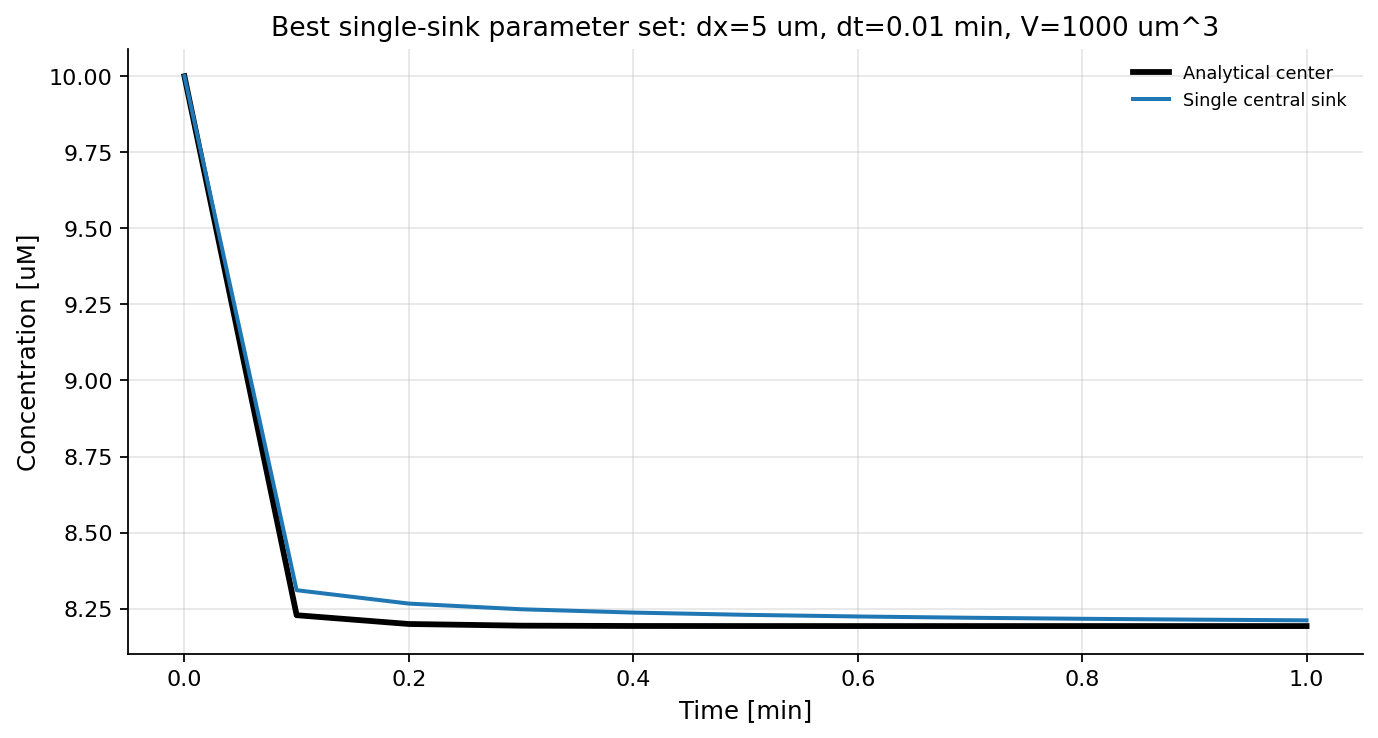

In [20]:
best_single_sink = run_metrics.sort_values(['mean_relative_error_percent', 'mean_absolute_error_uM']).iloc[0]

single_sink_target = all_runs[
    (all_runs['dx_um'] == best_single_sink['dx_um'])
    & (all_runs['dt_diffusion_min'] == best_single_sink['dt_diffusion_min'])
    & (all_runs['total_volume_um3'] == best_single_sink['total_volume_um3'])
].copy()
single_sink_target = single_sink_target.merge(analytical_df, on='time_min', how='inner', validate='many_to_one')
single_sink_target['absolute_error_uM'] = (single_sink_target['origin_center_uM'] - single_sink_target['center_concentration_uM']).abs()
single_sink_target['relative_error_percent'] = 100.0 * single_sink_target['absolute_error_uM'] / single_sink_target['center_concentration_uM'].abs()

comparison_table = pd.DataFrame([{
    'approach': 'single central sink',
    'dx_um': best_single_sink['dx_um'],
    'dt_diffusion_min': best_single_sink['dt_diffusion_min'],
    'total_volume_um3': best_single_sink['total_volume_um3'],
    'mean_absolute_error_uM': single_sink_target['absolute_error_uM'].mean(),
    'mean_relative_error_percent': single_sink_target['relative_error_percent'].mean(),
}])
display(comparison_table)

fig, axis = plt.subplots(figsize=(8.5, 4.5), constrained_layout=True)
axis.plot(analytical_df['time_min'], analytical_df['center_concentration_uM'], color='black', linewidth=2.6, label='Analytical center')
axis.plot(single_sink_target['time_min'], single_sink_target['origin_center_uM'], linewidth=1.8, label='Single central sink')
axis.set_xlabel('Time [min]')
axis.set_ylabel('Concentration [uM]')
axis.set_title(f'Best single-sink parameter set: dx={best_single_sink["dx_um"]:g} um, dt={best_single_sink["dt_diffusion_min"]:g} min, V={best_single_sink["total_volume_um3"]:g} um^3')
style_axis(axis)
axis.legend(frameon=False)
plt.show()

## Results Interpretation

This sweep uses one sink cell at the origin, aligned with the central voxel for every grid resolution. The analytical reference is therefore the single-cell sink solution, rather than the 12-cell `Cellsatcenter` solution used by the original notebook.

The comparison isolates how voxel size, diffusion time step, and cell volume affect the single-sink result. Because the sink remains at the central voxel, changes across `dx_um` reflect spatial resolution rather than changes in sink placement.